In [38]:
import requests
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
%matplotlib inline
from datetime import date, timedelta

In [39]:
print(os.path.exists(".env"))

True


In [40]:
with open(".env", "r") as dosya:
    icerik = dosya.read().strip()
    api_key = icerik.split("=")[1] 
    
print("Şifrenin başı:", api_key[:2], "...")

Şifrenin başı: FB ...


In [41]:


hisse = "AAPL"
carpan = "1"
bugun = date.today()
zaman_dilimi = "day"
bitis = bugun - timedelta(days=1) 
baslangic = bitis - timedelta(days=90)

url = f"https://api.massive.com/v2/aggs/ticker/{hisse}/range/{carpan}/{zaman_dilimi}/{baslangic}/{bitis}?adjusted=true&sort=asc&limit=90&apiKey={api_key}"

cevap = requests.get(url)
api_data = cevap.json()

print("Verinin genel yapısı (Anahtarlar):", api_data.keys())

if "results" in api_data:
    print("\nİlk günün ham verisi:")
    print(api_data["results"][0])
else:
    print("\nBir hata oldu sanırım, gelen mesaj:", api_data)

Verinin genel yapısı (Anahtarlar): dict_keys(['ticker', 'queryCount', 'resultsCount', 'adjusted', 'results', 'status', 'request_id', 'count'])

İlk günün ham verisi:
{'v': 50409078.0, 'vw': 274.5069, 'o': 280.15, 'c': 274.11, 'h': 280.15, 'l': 272.84, 't': 1765774800000, 'n': 723431}


In [42]:
apple_df = pd.DataFrame(api_data['results'])

apple_df.head()

,v,vw,o,c,h,l,t,n
0,50409078.0,274.5069,280.150,274.11,280.15,272.84,1765774800000,723431
1,37648628.0,273.8761,272.820,274.61,275.50,271.79,1765861200000,569202
2,50138743.0,272.9914,275.010,271.84,276.16,271.64,1765947600000,624189
3,51630721.0,271.3364,273.605,272.19,273.63,266.95,1766034000000,658922
4,144632048.0,272.8448,272.145,273.67,274.60,269.90,1766120400000,690849


In [43]:
apple_df['date'] = pd.to_datetime(apple_df['t'], unit='ms')

apple_df = apple_df.set_index('date')

apple_df.head()

,v,vw,o,c,h,l,t,n
date,,,,,,,,
2025-12-15 05:00:00,50409078.0,274.5069,280.150,274.11,280.15,272.84,1765774800000,723431
2025-12-16 05:00:00,37648628.0,273.8761,272.820,274.61,275.50,271.79,1765861200000,569202
2025-12-17 05:00:00,50138743.0,272.9914,275.010,271.84,276.16,271.64,1765947600000,624189
2025-12-18 05:00:00,51630721.0,271.3364,273.605,272.19,273.63,266.95,1766034000000,658922
2025-12-19 05:00:00,144632048.0,272.8448,272.145,273.67,274.60,269.90,1766120400000,690849


In [44]:
apple_df = apple_df.rename(columns={
    'o': 'open',  
    'c': 'close',  
    'h': 'high', 
    'l': 'low'      
})

apple_df.head()

,v,vw,open,close,high,low,t,n
date,,,,,,,,
2025-12-15 05:00:00,50409078.0,274.5069,280.150,274.11,280.15,272.84,1765774800000,723431
2025-12-16 05:00:00,37648628.0,273.8761,272.820,274.61,275.50,271.79,1765861200000,569202
2025-12-17 05:00:00,50138743.0,272.9914,275.010,271.84,276.16,271.64,1765947600000,624189
2025-12-18 05:00:00,51630721.0,271.3364,273.605,272.19,273.63,266.95,1766034000000,658922
2025-12-19 05:00:00,144632048.0,272.8448,272.145,273.67,274.60,269.90,1766120400000,690849


In [45]:
apple_df = apple_df.rename(columns={'v': 'volume'})

apple_df = apple_df.drop(columns=['t', 'vw', 'n'])

apple_df.head()

,volume,open,close,high,low
date,,,,,
2025-12-15 05:00:00,50409078.0,280.150,274.11,280.15,272.84
2025-12-16 05:00:00,37648628.0,272.820,274.61,275.50,271.79
2025-12-17 05:00:00,50138743.0,275.010,271.84,276.16,271.64
2025-12-18 05:00:00,51630721.0,273.605,272.19,273.63,266.95
2025-12-19 05:00:00,144632048.0,272.145,273.67,274.60,269.90


Text(0.5, 1.0, 'Apple Hisse Senedi Kapanış Fiyatları (Son 90 Gün)')

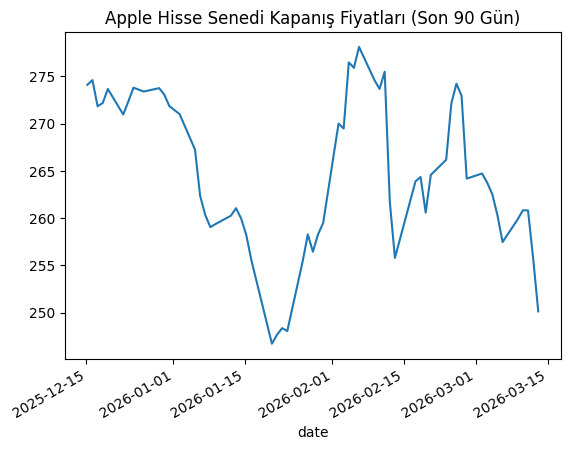

In [46]:
apple_df['close'].plot()

plt.title("Apple Hisse Senedi Kapanış Fiyatları (Son 90 Gün)")

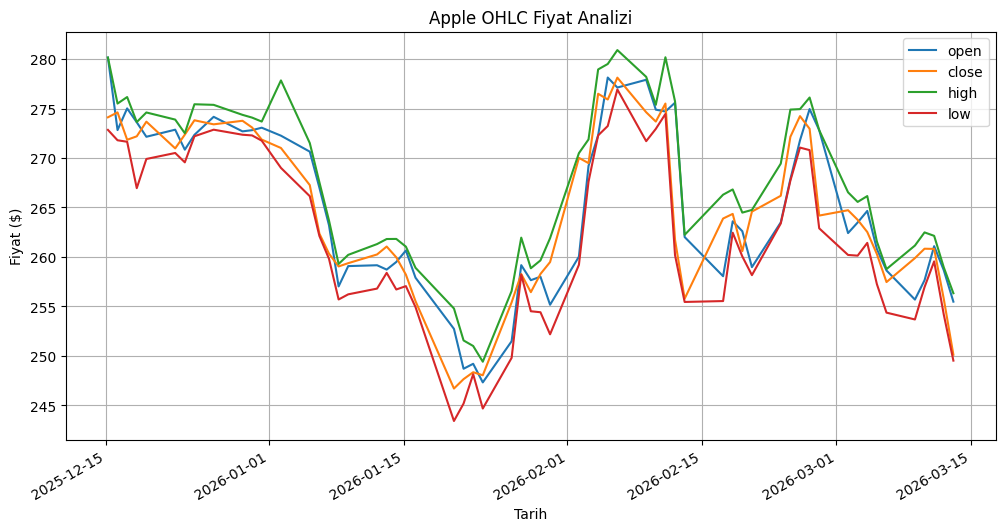

In [47]:
apple_df[['open', 'close', 'high', 'low']].plot(figsize=(12, 6))

plt.title("Apple OHLC Fiyat Analizi")
plt.xlabel("Tarih")
plt.ylabel("Fiyat ($)")
plt.grid(True) 

In [48]:
from nbresult import ChallengeResult

result = ChallengeResult('apple',
    index_name=apple_df.index.name,
    index_type=apple_df.index.dtype,
    columns=apple_df.columns
)

result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/elf/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/elf/code/elifcal/workintech-projects/data-stock-market/tests
plugins: typeguard-4.4.2, anyio-4.8.0
collecting ... collected 3 items

test_apple.py::TestApple::test_apple_df_columns PASSED                   [ 33%]
test_apple.py::TestApple::test_apple_df_index_is_timestamp PASSED        [ 66%]
test_apple.py::TestApple::test_apple_df_index_name_is_date PASSED        [100%]

============================== 3 passed in 0.45s ===============================


💯 You can commit your code:

git add tests/apple.pickle

git commit -m 'Completed apple step'

git push origin master

